# Machine Learning Pipeline for Genetic Disorder Classification

## 1. Setup and Libraries

In [342]:
import pandas as pd
import numpy as np
import warnings
import os
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import joblib
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from matplotlib.colors import ListedColormap

In [110]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [111]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## 2. Data Acquisition

In [117]:
train_df = pd.read_csv("dataset/train_genetic_disorders.csv")
test_df = pd.read_csv("dataset/test_genetic_disorders.csv")

In [118]:
train_df = train_df.sample(frac=0.5, random_state=RANDOM_STATE)
test_df = test_df.sample(frac=0.5, random_state=RANDOM_STATE)

In [119]:
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"\nFeatures: {train_df.shape[1]}")

Training samples: 11,042
Test samples: 4,732

Features: 45


In [115]:
train_df.head(1)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
16316,PID0xeab,12.0,No,No,No,No,5.056471,Robert,NaN,Arrius,...,Multiple,6.040263,slightly abnormal,1.0,1.0,1.0,0.0,NaN,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy


In [307]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8587 entries, 16316 to 7960
Data columns (total 45 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        8587 non-null   object 
 1   Patient Age                                       8080 non-null   float64
 2   Genes in mother's side                            8587 non-null   object 
 3   Inherited from father                             8491 non-null   object 
 4   Maternal gene                                     7582 non-null   object 
 5   Paternal gene                                     8587 non-null   object 
 6   Blood cell count (mcL)                            8587 non-null   float64
 7   Patient First Name                                8587 non-null   object 
 8   Family Name                                       5181 non-null   object 
 9   Father's name       

## 3. Preprocessing

### 3.1 Prepare Features and Target

In [122]:
target_col = "Genetic Disorder"
subclass_col = "Disorder Subclass"

In [123]:
drop_cols = [
    "Patient Id",
    "Patient First Name",
    "Family Name",
    "Father's name"
]

In [250]:
train_df = train_df.dropna(subset=[target_col, subclass_col]).copy()

y = train_df[target_col].astype(str)
class_names = sorted(y.unique())
class_map = {label: idx for idx, label in enumerate(class_names)}
y_encoded = y.map(class_map)

y_subclass = train_df[subclass_col].astype(str)
subclass_names = sorted(y_subclass.unique())
subclass_map = {label: idx for idx, label in enumerate(subclass_names)}
y_subclass_encoded = y_subclass.map(subclass_map)

X = train_df.drop(columns=[target_col, subclass_col] + drop_cols, errors="ignore")
test_df = test_df.drop(columns=drop_cols, errors="ignore")
common_cols = X.columns.intersection(test_df.columns)
X = X[common_cols]
test_df = test_df[common_cols]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print(f"Cleaned Dataset: {X.shape[0]} rows")
print(f"Target Classes: {class_names}")

Cleaned Dataset: 8587 rows
Target Classes: ['Mitochondrial genetic inheritance disorders', 'Multifactorial genetic inheritance disorders', 'Single-gene inheritance diseases']


### 3.2 Visualize Missing Data

In [251]:
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])
mean_num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="mean"))])
median_num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
knn_pipeline = Pipeline([("imputer", KNNImputer(n_neighbors=5, weights="uniform"))])

In [252]:
mean_preprocessor = ColumnTransformer(
    transformers=[
        ("num", mean_num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)
median_preprocessor = ColumnTransformer(
    transformers=[
        ("num", median_num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)
knn_preprocessor = ColumnTransformer(
    transformers=[("num", knn_pipeline, num_cols), ("cat", cat_pipeline, cat_cols)]
)

In [253]:
def transform_and_rebuild(preprocessor, X):
    X_transformed = preprocessor.fit_transform(X)
    all_columns = num_cols.tolist() + cat_cols.tolist()
    return pd.DataFrame(X_transformed, columns=all_columns)

In [254]:
X_mean = transform_and_rebuild(mean_preprocessor, X)
X_median = transform_and_rebuild(median_preprocessor, X)
X_knn = transform_and_rebuild(knn_preprocessor, X)

2026/02/15 13:56:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '880c10d5f35e4542bed7dceb09c12a40', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:56:03 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/02/15 13:56:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7d294e5daaab4269bfc71c2dc8636076', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:56:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/02/15

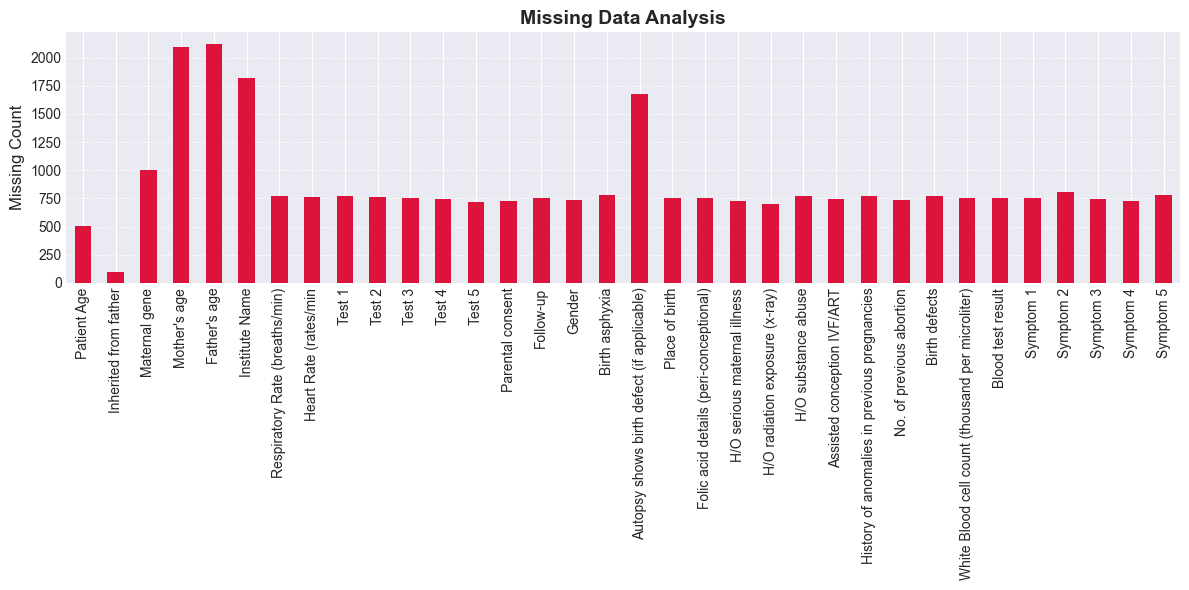

In [313]:
import matplotlib.pyplot as plt

def plot_missing(data, ax, title, color):
    missing = data.isnull().sum()
    missing_only = missing[missing > 0]
    
    if not missing_only.empty:
        missing_only.plot(kind="bar", ax=ax, color=color)
        ax.set_title(title, fontweight="bold", fontsize=14)
        ax.set_ylabel("Missing Count", fontsize=12)
        ax.tick_params(axis="x", rotation=90)
    else:
        ax.text(0.5, 0.5, 'No Missing Values Found', 
                horizontalalignment='center', verticalalignment='center', 
                fontsize=14, fontweight='bold')
        ax.set_title(title, fontweight="bold")
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)

fig, ax = plt.subplots(figsize=(12, 6))

plot_missing(X, ax, "Missing Data Analysis", color='crimson')
plt.tight_layout()
plt.show()

### 3.3 Feature Engineering Pipeline

In [314]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [258]:
num_transformer = Pipeline([
    ('impute', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [259]:
X_processed = preprocessor.fit_transform(X)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

2026/02/15 13:56:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4d0a39fb678a45468f48ea3e95f8fcc5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:56:29 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/02/15 13:56:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7c877b1159ad46ad94674e8c9629a7ae', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:56:30 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


In [260]:
ohe_feature_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
all_features = num_cols + list(ohe_feature_names)
X_final_df = pd.DataFrame(X_processed, columns=all_features)

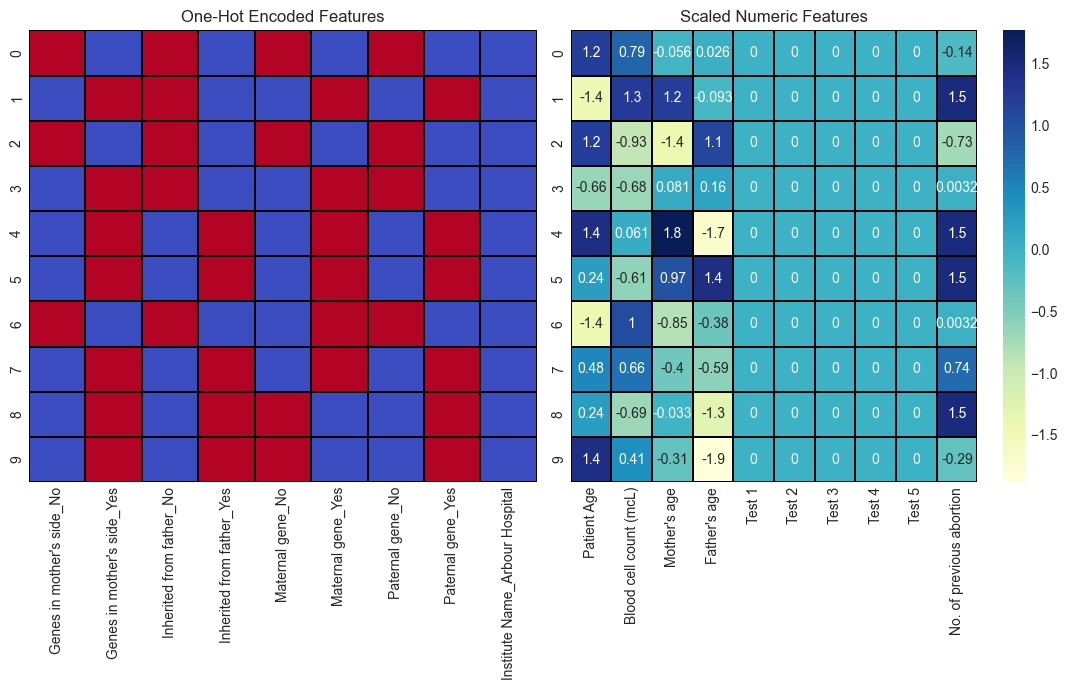

In [322]:
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
sns.heatmap(X_final_df[ohe_feature_names[:9]].head(10), cmap="coolwarm", ax=axes[0], cbar=False , linecolor='black' , linewidths=0.1)
axes[0].set_title("One-Hot Encoded Features")
sns.heatmap(X_final_df[num_cols[:10]].head(10), annot=True, cmap="YlGnBu", ax=axes[1], linecolor='black' , linewidths=0.1)
axes[1].set_title("Scaled Numeric Features")
plt.tight_layout()
plt.show()

In [323]:
print(f"Target Mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

Target Mapping: {'Mitochondrial genetic inheritance disorders': np.int64(0), 'Multifactorial genetic inheritance disorders': np.int64(1), 'Single-gene inheritance diseases': np.int64(2)}


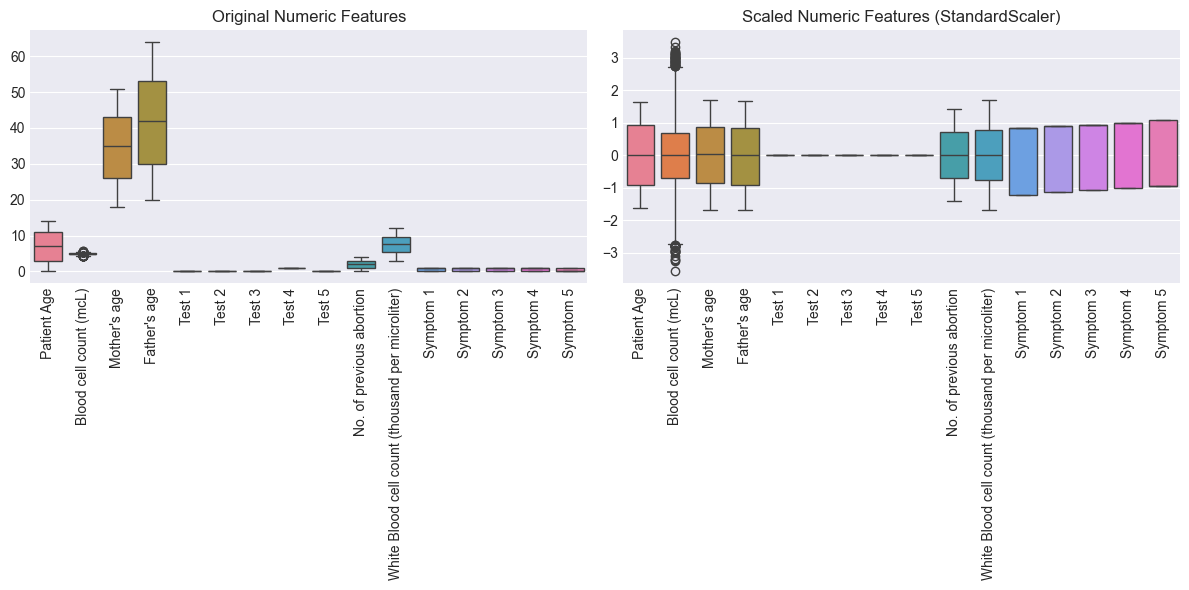

In [324]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=X[num_cols], ax=axes[0])
axes[0].set_title('Original Numeric Features')
axes[0].tick_params(axis='x', rotation=90)
sns.boxplot(data=X_scaled[num_cols], ax=axes[1])
axes[1].set_title('Scaled Numeric Features (StandardScaler)')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### 3.4 Train-Validation Split

In [264]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_encoded
)

In [265]:
pca_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE))
])

In [266]:
X_train_pca = pca_pipe.fit_transform(X_train)
X_val_pca = pca_pipe.transform(X_val)

2026/02/15 13:56:49 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e823a745258240198c93783b3a285990', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:56:52 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


In [267]:
pca = pca_pipe.named_steps['pca']

In [268]:
print(f"Reduced dimensions: {X_train_pca.shape[1]}")
print(f"Total Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Reduced dimensions: 40
Total Explained variance: 0.9538


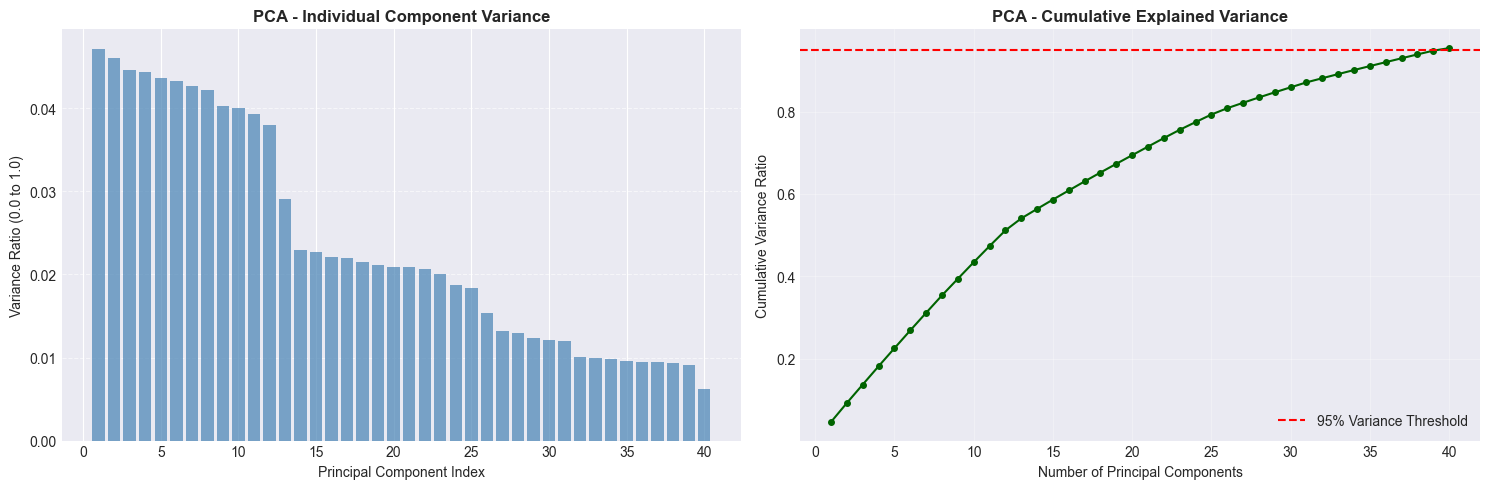

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
var_ratio = pca.explained_variance_ratio_
cumsum = np.cumsum(var_ratio)
axes[0].bar(range(1, len(var_ratio) + 1), var_ratio, color='steelblue', alpha=0.7)
axes[0].set_title('PCA - Individual Component Variance', fontweight='bold')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Variance Ratio (0.0 to 1.0)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].plot(range(1, len(cumsum) + 1), cumsum, marker='o', color='darkgreen', markersize=4)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
axes[1].set_title('PCA - Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 Handle Class Imbalance with SMOTE

In [270]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

2026/02/15 13:57:10 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f1c7425b32b94ac5b89a5187e24bec8b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:57:10 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/02/15 13:57:10 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cd4a8174918e46cb98052c4eb54baa05', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/15 13:57:10 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


In [271]:
datasets = [
    (y_train, 'BEFORE SMOTE', 'salmon'),
    (y_train_smote, 'AFTER SMOTE', 'skyblue')
]

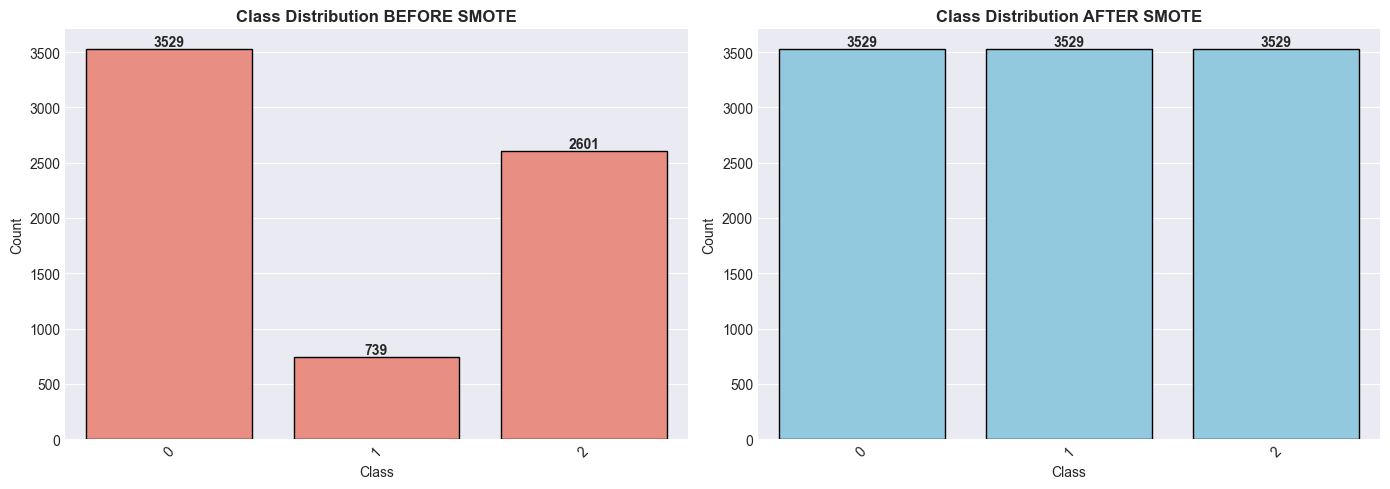

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (data, title, color) in enumerate(datasets):
    counts = pd.Series(data).value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], color=color, edgecolor='black')

    axes[i].set_title(f'Class Distribution {title}', fontweight='bold')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [326]:
print(f"Shape Change: {X_train_pca.shape} -> {X_train_smote.shape}")
print(f"Final Counts:\n{pd.Series(y_train_smote).value_counts()}")

Shape Change: (6869, 40) -> (10587, 40)
Final Counts:
2    3529
0    3529
1    3529
Name: count, dtype: int64


## 4. MLflow Experiment Setup

Initialize MLflow for experiment tracking.

In [328]:
mlflow.set_tracking_uri("file:./mlruns")
experiment_name = "Genetic_Disorder_Classification"
mlflow.set_experiment(experiment_name)
os.makedirs("models", exist_ok=True)
os.makedirs("mlruns", exist_ok=True)

In [329]:
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {experiment_name}")

MLflow tracking URI: file:./mlruns
Experiment: Genetic_Disorder_Classification


## 5. Utility Functions

In [275]:
def evaluate_model(model, X_val, y_val, model_name):

    y_pred = model.predict(X_val)
    metrics = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1_macro': f1_score(y_val, y_pred, average='macro'),
        'f1_weighted': f1_score(y_val, y_pred, average='weighted')
    }
    y_proba = None
    try:
        y_proba = model.predict_proba(X_val) if hasattr(model, 'predict_proba') else model.decision_function(X_val)
        metrics['roc_auc'] = roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro')
    except Exception:
        metrics['roc_auc'] = None
    print(f"\n{'='*40}\n{model_name.upper()} PERFORMANCE\n{'='*40}")
    for k, v in metrics.items():
        if v is not None:
            print(f"{k.replace('_', ' ').title():<15}: {v:.4f}")
    
    print("-" * 40)
    print("Classification Report:")
    
    print(classification_report(y_val, y_pred))
    return metrics, y_pred, y_proba

In [276]:
def plot_feature_importance(model, feature_names, title="Feature Importance", top_n=20):

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        print(f"Skipping: No importance attribute found for {title}")
        return

    indices = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(10, 6))

    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
    plt.title(title, fontweight='bold')
    
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [277]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    
    plt.title(title, fontweight="bold", pad=20)
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

In [332]:
def plot_model_dashboard(model, X_val, y_val, y_pred, feature_names, class_names, title_prefix="Model"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,cbar=False, ax=ax1)
    ax1.set_title(f"{title_prefix} - Confusion Matrix", fontweight="bold", pad=15)
    ax1.set_ylabel("True Label")
    ax1.set_xlabel("Predicted Label")

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        ax2.text(0.5, 0.5, "No feature importance available", ha='center')
        importances = None

    if importances is not None:
        top_n = min(20, len(feature_names))
        indices = np.argsort(importances)[-top_n:]
        
        sns.barplot(x=importances[indices], 
                    y=[feature_names[i] for i in indices], 
                    palette="viridis", ax=ax2)
        
        ax2.set_title(f"{title_prefix} - Top {top_n} Features", fontweight='bold', pad=15)
        ax2.set_xlabel('Importance Score')

    plt.tight_layout()
    plt.show()

## 6. Model Training and Evaluation

Training baseline and advanced models as outlined in the report.

### 6.1 Random Forest Classifier

In [279]:
rf_params = {
    "n_estimators": 300,    
    "max_depth": 10,        
    "min_samples_leaf": 5,  
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [280]:
with mlflow.start_run(run_name="Random_Forest"):

    mlflow.sklearn.autolog(log_models=False)
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train_smote, y_train_smote)

    rf_metrics, rf_pred, rf_proba = evaluate_model(
        rf_model, X_val_pca, y_val, "Random Forest"
    )

    mlflow.log_metrics({k: v for k, v in rf_metrics.items() if v is not None})

    mlflow.sklearn.log_model(rf_model, "model")
    joblib.dump(rf_model, "models/random_forest.pkl")

    print("Random Forest trained, evaluated, and logged to MLflow")

2026/02/15 13:57:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



RANDOM FOREST PERFORMANCE
Accuracy       : 0.5343
F1 Macro       : 0.4896
F1 Weighted    : 0.5268
Roc Auc        : 0.6902
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.67      0.66       882
           1       0.32      0.70      0.44       185
           2       0.51      0.30      0.38       651

    accuracy                           0.53      1718
   macro avg       0.49      0.56      0.49      1718
weighted avg       0.56      0.53      0.53      1718

Random Forest trained, evaluated, and logged to MLflow


In [281]:
class_names = [label for label, idx in sorted(class_map.items(), key=lambda item: item[1])]
pca_feature_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

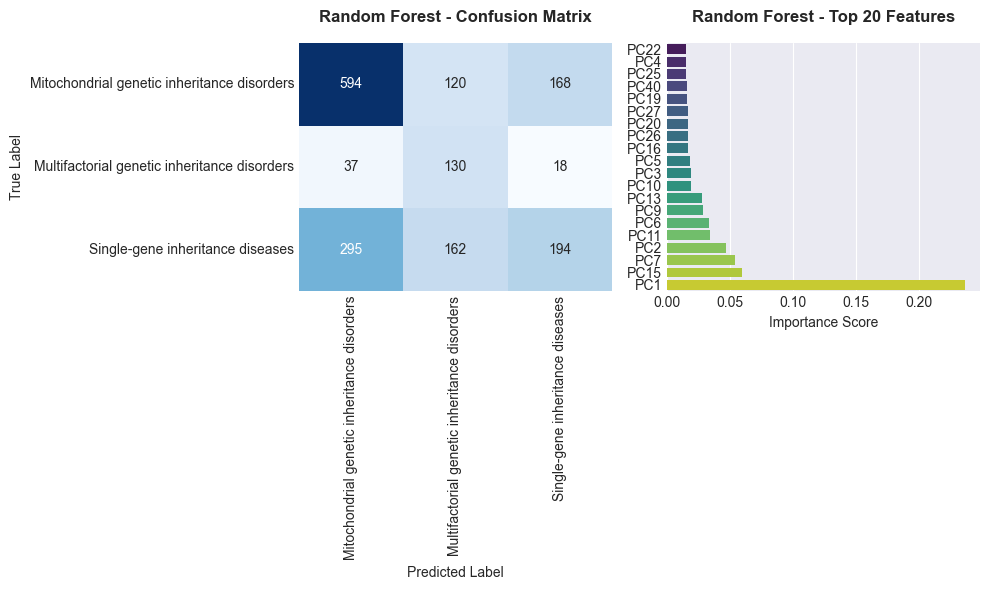

In [333]:
plot_model_dashboard(rf_model, X_val_pca, y_val, rf_pred, pca_feature_names, class_names, "Random Forest")

### 6.2 XGBoost Classifier

In [283]:
xgb_params = {
    "n_estimators": 300,
    "max_depth": 7,
    "learning_rate": 0.1,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "eval_metric": 'mlogloss',
    "use_label_encoder": False
}

In [284]:
import mlflow
import joblib
from xgboost import XGBClassifier

with mlflow.start_run(run_name="XGBoost"):
    
    mlflow.sklearn.autolog(log_models=False)
    xgb_model = XGBClassifier(**xgb_params)

    xgb_model.fit(
        X_train_smote, y_train_smote, eval_set=[(X_val_pca, y_val)], verbose=False
    )

    xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
        xgb_model, X_val_pca, y_val, "XGBoost"
    )

    mlflow.log_metrics({k: v for k, v in xgb_metrics.items() if v is not None})
    mlflow.sklearn.log_model(xgb_model, "model")
    joblib.dump(xgb_model, "models/xgboost.pkl")
    print("XGBoost trained with Early Stopping and logged to MLflow")

2026/02/15 13:58:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBOOST PERFORMANCE
Accuracy       : 0.5227
F1 Macro       : 0.4705
F1 Weighted    : 0.5168
Roc Auc        : 0.6816
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.66      0.62       882
           1       0.36      0.39      0.38       185
           2       0.46      0.38      0.41       651

    accuracy                           0.52      1718
   macro avg       0.47      0.47      0.47      1718
weighted avg       0.52      0.52      0.52      1718

XGBoost trained with Early Stopping and logged to MLflow


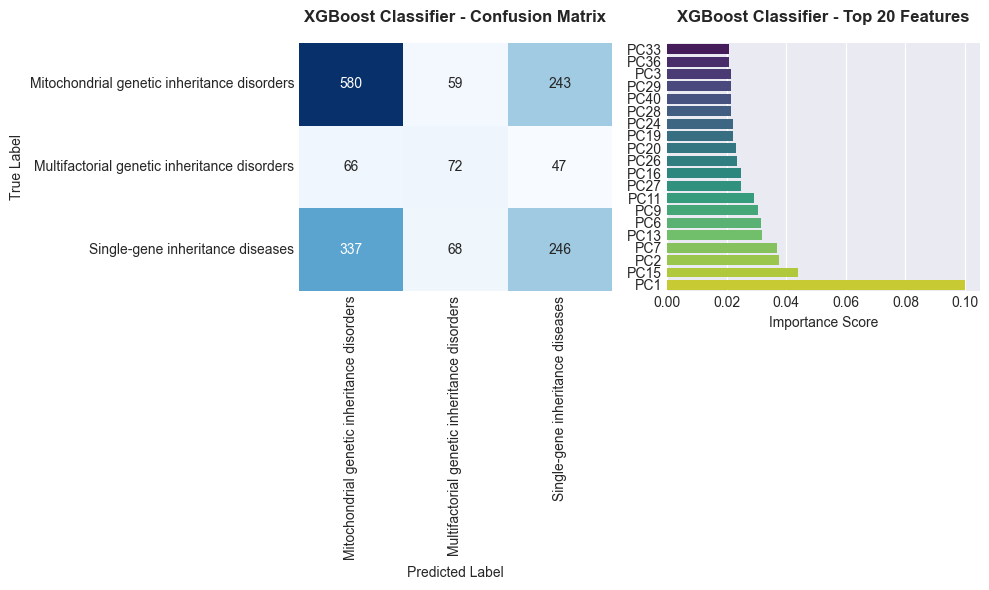

In [334]:
plot_model_dashboard(xgb_model, X_val_pca, y_val, xgb_pred, pca_feature_names, class_names, "XGBoost Classifier")

### 6.3 LightGBM Classifier

In [335]:
lgbm_params = {
    "n_estimators": 300,
    "max_depth": 7,
    "num_leaves": 31,
    "learning_rate": 0.1,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1 
}

In [290]:
with mlflow.start_run(run_name="LightGBM"):

    mlflow.sklearn.autolog(log_models=False)
    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(X_train_smote, y_train_smote)
    
    lgbm_metrics, lgbm_pred, lgbm_proba = evaluate_model(
        lgbm_model, X_val_pca, y_val, "LightGBM"
    )
    
    mlflow.log_metrics({k: v for k, v in lgbm_metrics.items() if v is not None})
    mlflow.sklearn.log_model(lgbm_model, "model")
    
    joblib.dump(lgbm_model, "models/lightgbm.pkl")
    print("LightGBM trained and logged to MLflow")

2026/02/15 13:59:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



LIGHTGBM PERFORMANCE
Accuracy       : 0.5076
F1 Macro       : 0.4582
F1 Weighted    : 0.5010
Roc Auc        : 0.6709
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60       882
           1       0.37      0.37      0.37       185
           2       0.44      0.36      0.40       651

    accuracy                           0.51      1718
   macro avg       0.46      0.46      0.46      1718
weighted avg       0.50      0.51      0.50      1718

LightGBM trained and logged to MLflow


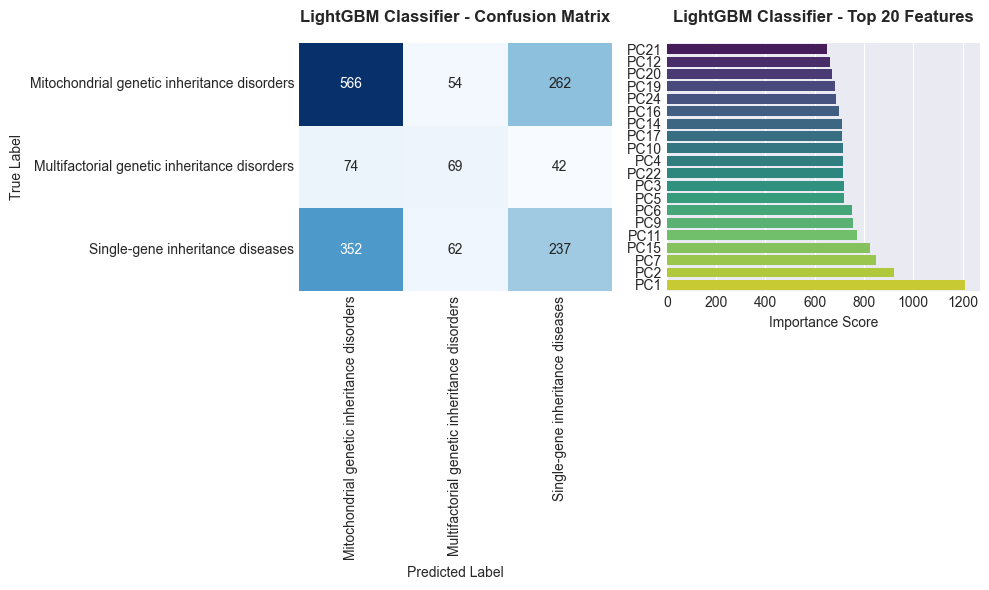

In [336]:
plot_model_dashboard(lgbm_model, X_val_pca, y_val, lgbm_pred, pca_feature_names, class_names, "LightGBM Classifier")

### 6.4 Support Vector Machine (SVM)

In [293]:
svm_params = {
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "scale",
    "class_weight": "balanced",
    "probability": True,
    "random_state": RANDOM_STATE
}

In [294]:
import mlflow
import joblib
from sklearn.svm import SVC

with mlflow.start_run(run_name="SVM"):

    mlflow.sklearn.autolog(log_models=False)
    svm_model = SVC(**svm_params)
    svm_model.fit(X_train_smote, y_train_smote)
    
    svm_metrics, svm_pred, svm_proba = evaluate_model(
        svm_model, X_val_pca, y_val, "SVM"
    )

    mlflow.log_metrics({k: v for k, v in svm_metrics.items() if v is not None})
    mlflow.sklearn.log_model(svm_model, "model")
    
    joblib.dump(svm_model, "models/svm.pkl")

    print("SVM trained and logged to MLflow")

2026/02/15 14:01:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



SVM PERFORMANCE
Accuracy       : 0.5605
F1 Macro       : 0.5071
F1 Weighted    : 0.5497
Roc Auc        : 0.7103
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       882
           1       0.38      0.49      0.43       185
           2       0.52      0.36      0.42       651

    accuracy                           0.56      1718
   macro avg       0.51      0.52      0.51      1718
weighted avg       0.56      0.56      0.55      1718

SVM trained and logged to MLflow


In [ ]:
def plot_svm_boundaries(model, X, y, class_names):
    X_plot = X.values[:, :2] if hasattr(X, 'values') else X[:, :2]
    y_plot = y.values if hasattr(y, 'values') else y

    h = .02
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    custom_cmap = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA'])
    
    plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.3)
    
    scatter = plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, 
                          cmap=custom_cmap, edgecolors='k', s=20)
    
    plt.xlabel('Principal Component 1', fontweight='bold')
    plt.ylabel('Principal Component 2', fontweight='bold')
    plt.title('SVM Decision Boundaries (PCA Space)', fontweight='bold')
    
    # Add a legend
    handles = scatter.legend_elements()[0]
    plt.legend(handles, class_names, title="Classes", loc="upper right")
    
    plt.grid(alpha=0.2)
    plt.show()

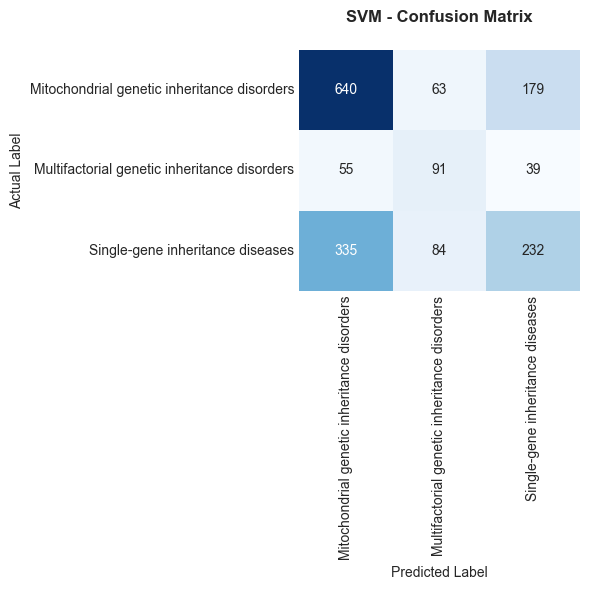

In [338]:
plot_confusion_matrix(y_val, svm_pred, class_names, "SVM - Confusion Matrix")

2026/02/15 14:24:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c5144bc0e311441fa3c87ec7279f8122', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


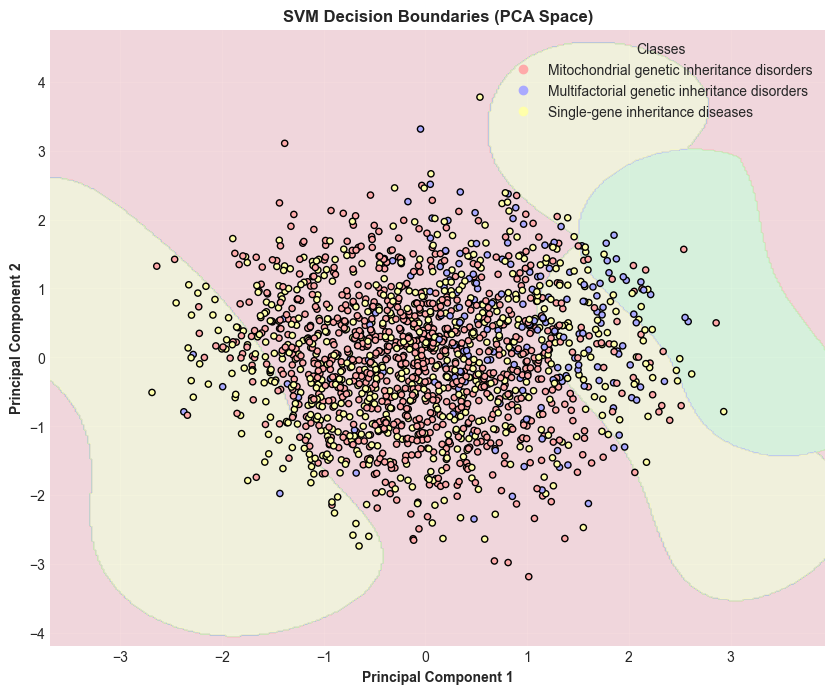

In [341]:
visual_svm = SVC(kernel='rbf', C=0.5).fit(X_train_pca[:, :2], y_train)
plot_svm_boundaries(visual_svm, X_val_pca, y_val, class_names)

### 6.5 Neural Network (PyTorch)

In [343]:
class GeneticDisorderNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=3, dropout_rate=0.3):
        super(GeneticDisorderNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

In [297]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [298]:
def to_tensor(data):
    return torch.tensor(data.values if hasattr(data, 'values') else data)

In [299]:
X_train_t = to_tensor(X_train_smote).float().to(device)
y_train_t = to_tensor(y_train_smote).long().to(device)
X_val_t = to_tensor(X_val_pca).float().to(device)
y_val_t = to_tensor(y_val).long().to(device)

In [300]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

In [301]:
with mlflow.start_run(run_name="Neural_Network"):

    params = {"hidden_dim": 256, "lr": 0.001, "epochs": 100, "dropout": 0.3}
    mlflow.log_params(params)

    num_classes = len(torch.unique(y_train_t))
    nn_model = GeneticDisorderNN(X_train_t.shape[1], params["hidden_dim"], num_classes).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(nn_model.parameters(), lr=params["lr"])

    print(f"Training on {device}...")

    for epoch in range(params["epochs"]):
        nn_model.train()
        optimizer.zero_grad()
        
        outputs = nn_model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 20 == 0:
            nn_model.eval()
            with torch.no_grad():
                v_loss = criterion(nn_model(X_val_t), y_val_t)
                print(f"Epoch {epoch+1}/{params['epochs']} | Train Loss: {loss.item():.4f} | Val Loss: {v_loss.item():.4f}")

    

    nn_model.eval()
    with torch.no_grad():
        logits = nn_model(X_val_t)
        nn_proba = torch.softmax(logits, dim=1).cpu().numpy()
        nn_pred = np.argmax(nn_proba, axis=1)

    nn_metrics = {
        'accuracy': accuracy_score(y_val, nn_pred),
        'f1_macro': f1_score(y_val, nn_pred, average='macro'),
        'f1_weighted': f1_score(y_val, nn_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_val, nn_proba, multi_class='ovr', average='macro')
    }

    mlflow.log_metrics({k: v for k, v in nn_metrics.items() if v is not None})
    mlflow.pytorch.log_model(nn_model, "model")
    torch.save(nn_model.state_dict(), "models/neural_network.pth")

Training on cpu...
Epoch 20/100 | Train Loss: 0.8425 | Val Loss: 0.8945
Epoch 40/100 | Train Loss: 0.7792 | Val Loss: 0.9115
Epoch 60/100 | Train Loss: 0.7342 | Val Loss: 0.9175
Epoch 80/100 | Train Loss: 0.6876 | Val Loss: 0.9166


2026/02/15 14:02:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/15 14:02:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch 100/100 | Train Loss: 0.6545 | Val Loss: 0.9284


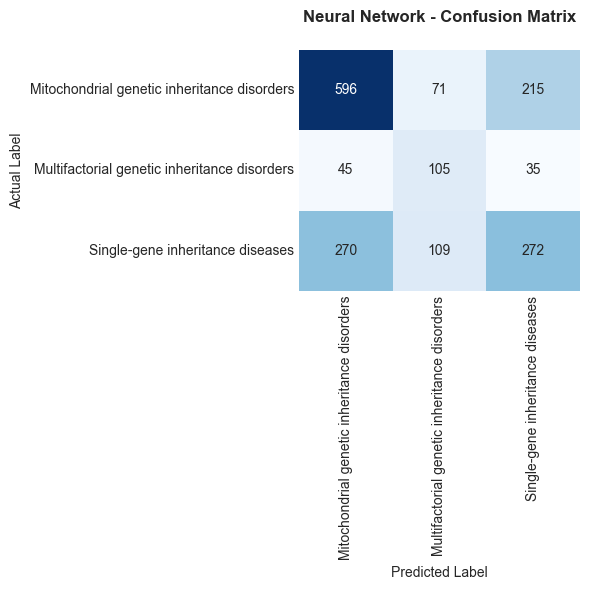

In [339]:
t_loss = train_losses if 'train_losses' in locals() else []
v_loss = val_losses if 'val_losses' in locals() else []

if not t_loss:
    print("Warning: No loss data found. Ensure the training loop ran successfully.")
else:
    plt.figure(figsize=(12, 6))
    plt.plot(t_loss, label='Training Loss', color='steelblue', linewidth=2, alpha=0.8)
    plt.plot(v_loss, label='Validation Loss', color='darkorange', linewidth=2)
    min_val_idx = np.argmin(v_loss)
    plt.scatter(min_val_idx, v_loss[min_val_idx], color='red', s=50, zorder=5,label=f'Best Model (Epoch {min_val_idx+1})')
    plt.title('Neural Network Training Convergence', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Cross-Entropy Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, facecolor='white', shadow=True)
    
    plt.tight_layout()
    plt.show()

if 'nn_pred' in locals() and 'class_names' in locals():
    plot_confusion_matrix(y_val, nn_pred, class_names, "Neural Network - Confusion Matrix")
else:
    print("Error: nn_pred or class_names not found. Check prediction step.")

<Figure size 400x400 with 0 Axes>

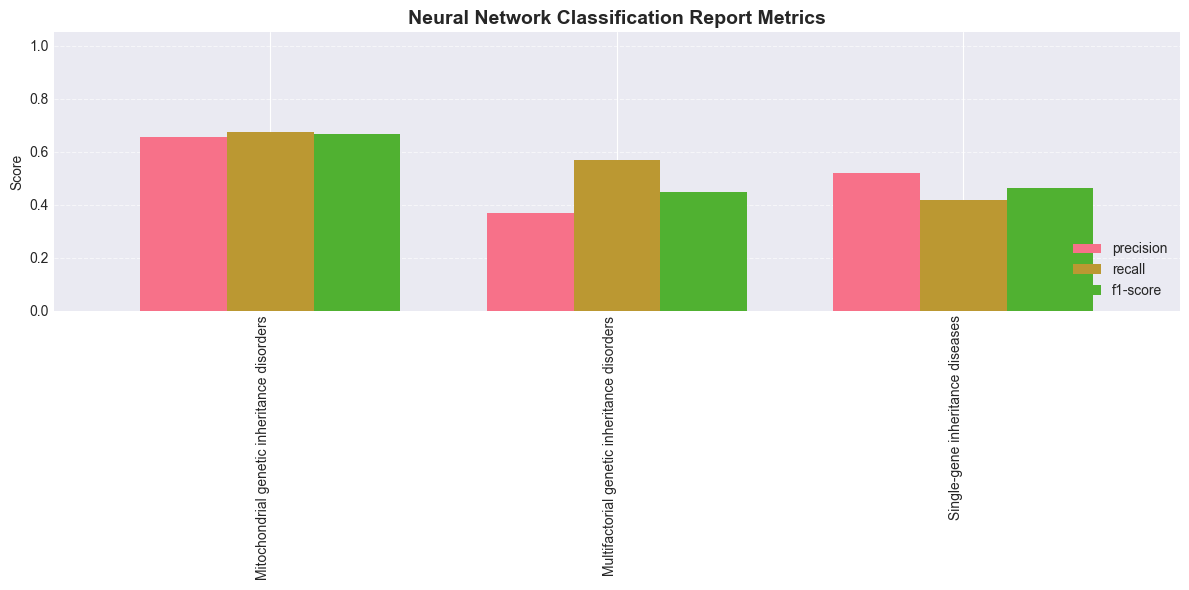

In [354]:
if 'nn_pred' in locals() and 'class_names' in locals():
    report = classification_report(
        y_val,
        nn_pred,
        target_names=class_names,
        output_dict=True
    )

    df_report = pd.DataFrame(report).T
    df_report = df_report.iloc[:len(class_names)]

    plt.figure(figsize=(4, 4))
    plt.tight_layout()
    df_report[["precision", "recall", "f1-score"]].plot(
        kind="bar",
        figsize=(12, 6),
        width=0.75
    )

    plt.title("Neural Network Classification Report Metrics", fontsize=14, fontweight="bold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=90, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

else:
    print("Error: nn_pred or class_names not found. Run prediction first.")


## 7. Cross-Validation

Stratified K-Fold cross-validation for robust performance estimates.

In [303]:
from imblearn.pipeline import Pipeline as ImbPipeline

In [304]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

models_cv = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, 
        max_depth=8,             
        min_samples_leaf=5,     
        class_weight='balanced', 
        random_state=RANDOM_STATE, 
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=250, 
        max_depth=4,            
        learning_rate=0.05,        
        reg_alpha=0.5,           
        reg_lambda=1.5,            
        random_state=RANDOM_STATE, 
        n_jobs=-1, 
        eval_metric='mlogloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=250, 
        max_depth=4, 
        num_leaves=15,            
        learning_rate=0.05, 
        subsample=0.8,            
        colsample_bytree=0.8,     
        random_state=RANDOM_STATE, 
        n_jobs=-1, 
        verbose=-1
    ),
    'SVM': SVC(
        kernel='rbf', 
        C=0.5,              
        class_weight='balanced', 
        random_state=RANDOM_STATE, 
        probability=True
    )
}

In [305]:
def create_leak_proof_pipeline(model):
    return ImbPipeline(
        [
            ("preprocessor", preprocessor),
            ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("classifier", model),
        ]
    )

In [306]:
final_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Starting Final Evaluation...")

for name, model in models_cv.items():
    print(f"Checking {name}...")
    pipeline = create_leak_proof_pipeline(model)
    
    try:
        cv_output = cross_validate(
            pipeline, X, y_encoded, 
            cv=kf, 
            scoring='f1_macro', 
            return_train_score=True, 
            n_jobs=-1
        )
        
        train_f1 = np.nanmean(cv_output['train_score'])
        test_f1 = np.nanmean(cv_output['test_score'])
        
        final_results[name] = {
            'Train F1': train_f1,
            'Test F1': test_f1,
            'Gap': train_f1 - test_f1
        }
    except Exception as e:
        print(f"Error evaluating {name}: {e}")

results_df = pd.DataFrame(final_results).T.sort_values(by='Test F1', ascending=False)

print("\n" + "="*50)
print("FINAL LEAK-PROOF PERFORMANCE")
print("="*50)
print(results_df)

Starting Final Evaluation...
Checking Random Forest...
Checking XGBoost...
Checking LightGBM...
Checking SVM...

FINAL LEAK-PROOF PERFORMANCE
               Train F1   Test F1       Gap
Random Forest  0.753574  0.497465  0.256109
LightGBM       0.765883  0.495970  0.269913
SVM            0.712711  0.494647  0.218065
XGBoost        0.729551  0.493835  0.235716


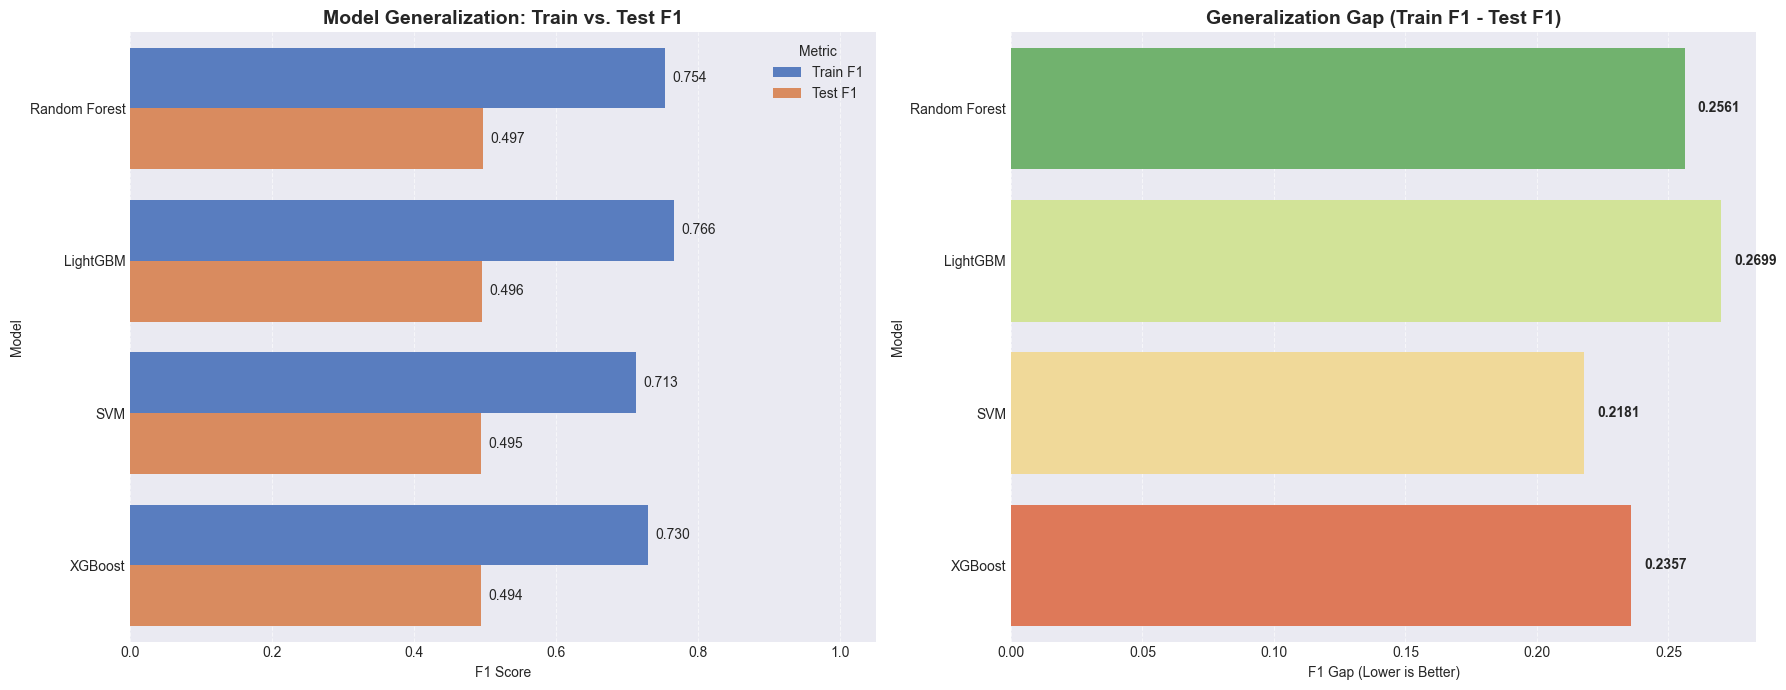

In [355]:
plot_df = results_df.reset_index().rename(columns={'index': 'Model'})

melted_df = plot_df.melt(id_vars='Model', value_vars=['Train F1', 'Test F1'], var_name='Metric', value_name='F1 Score')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=melted_df, x='F1 Score', y='Model', hue='Metric', ax=ax1, palette='muted')
ax1.set_title('Model Generalization: Train vs. Test F1', fontweight='bold', fontsize=14)
ax1.set_xlim(0, 1.05) 
ax1.grid(axis='x', linestyle='--', alpha=0.6)

for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.3f}', 
                 va='center', fontsize=10)

sns.barplot(data=plot_df, x='Gap', y='Model', ax=ax2, palette='RdYlGn_r')
ax2.set_title('Generalization Gap (Train F1 - Test F1)', fontweight='bold', fontsize=14)
ax2.set_xlabel('F1 Gap (Lower is Better)')
ax2.grid(axis='x', linestyle='--', alpha=0.6)

for i, gap in enumerate(plot_df['Gap']):
    if not np.isnan(gap):
        ax2.text(gap + 0.005, i, f'{gap:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()